# 4.4. 模型选择、欠拟合和过拟合

模型要发现泛化模式，这个东西类似刷题和考试，题刷好了考试不一定好，虽然和相关度有关系。总之，不能把考试当题来刷了，就像说高考题总是去年的简单一样

#### **训练误差&泛化误差**

真正关心的东西是**泛化误差**，就是真正的考试（实战）。

#### **K-则交叉验证**
在训练数据不足时，可以交叉测验取平均值，类似化学实验中减少误差

将训练数据分为k份：

`for i in range(k)`为测试集，对其余部分训练即可

#### **过拟合(over-fitting)&欠拟合(under-fitting)**
字面意思，做前几年的题回回150，你考试绝对比150低，做前几年的题随便糊弄70分，考试认真点但是因为平常不认真只能考100来分。

1. 模型复杂的话数据过少训练不到位——欠拟合；
3. 模型简单若数据太多的话过于简单——过拟合。

总的目标是泛化误差小。所以需要针对不同的模型要找到模型容量的平衡点

##### **小结**：
深度学习先吃饱数据（过拟合），调整容量来减小泛化误差。

#### **VC维**
（统计学习理论）对一个分类模型，VC=最大集大小，使得任意标号给定方式，都存在一个完美模型能进行一个完美分类。

但是在深度学习中，VC维太难算了，难以应用到复杂模型中

后面不知道是啥玩意儿，当练一练代码能力？

e.g生成下面的多项式的数据集：
<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>y</mi>
  <mo>=</mo>
  <mn>5</mn>
  <mo>+</mo>
  <mn>1.2</mn>
  <mi>x</mi>
  <mo>&#x2212;</mo>
  <mn>3.4</mn>
  <mfrac>
    <msup>
      <mi>x</mi>
      <mn>2</mn>
    </msup>
    <mrow>
      <mn>2</mn>
      <mo>!</mo>
    </mrow>
  </mfrac>
  <mo>+</mo>
  <mn>5.6</mn>
  <mfrac>
    <msup>
      <mi>x</mi>
      <mn>3</mn>
    </msup>
    <mrow>
      <mn>3</mn>
      <mo>!</mo>
    </mrow>
  </mfrac>
  <mo>+</mo>
  <mi>&#x3F5;</mi>
  <mtext>&#xA0;where&#xA0;</mtext>
  <mi>&#x3F5;</mi>
  <mo>&#x223C;</mo>
  <mrow data-mjx-texclass="ORD">
    <mi data-mjx-variant="-tex-calligraphic" mathvariant="script">N</mi>
  </mrow>
  <mo stretchy="false">(</mo>
  <mn>0</mn>
  <mo>,</mo>
  <msup>
    <mn>0.1</mn>
    <mn>2</mn>
  </msup>
  <mo stretchy="false">)</mo>
  <mo>.</mo>
</math>

In [1]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l
from py_proj import functions_needed

In [2]:
max_degree = 20
true_w = np.zeros(max_degree)
n_train, n_test = 100, 100
true_w[0: 4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_test+n_train, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1,-1))
#上面用了广播机制，把[x]变成[x^0, x, x^2,……]，而且x^0已经成为了偏置bias，不需再设一个b

for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)

labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

##### **训练并测试**

In [14]:
true_w, features, poly_features, labels = [torch.tensor(x, dtype=torch.float32) 
                            for x in [true_w, features, poly_features, labels]] 

C:\Users\，\AppData\Local\Temp\ipykernel_10732\914978431.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_w, features, poly_features, labels = [torch.tensor(x, dtype=torch.float32)


定义损失

In [15]:
def evaluate_loss(net, data_iter, loss):
    metric = functions_needed.Accumulator(2)
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())

    return metric[0]/metric[1]

定义训练函数

In [19]:
def train(train_features, test_features, train_labels, test_labels
          ,num_epochs=400):
    loss = nn.MSELoss()
    input_shape = train_features.shape[-1]
    net = nn.Sequential(nn.Linear(input_shape, 1, bias = False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),
                                batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr = 0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        functions_needed.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())
    

In [17]:
print(poly_features[:n_train, :4].shape,'/n', labels[:n_train].reshape(-1,1).shape)

torch.Size([100, 4]) /n torch.Size([100, 1])


*这里debug成功了（靠，好像是第一次没有借助ai进行debug）。下面一个代码块里面弹出来了type.error，看仔细了发现是`load_array`函数中调用`dataset`部分，出现了size对不上的问题。仔细看之后一层层倒推发现是`poly_features`并未转换为张量形式，转换即可*

weight: [[ 5.001577   1.2132082 -3.4025528  5.561014 ]]


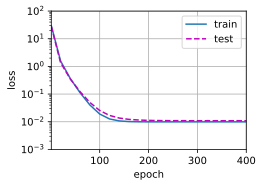

In [20]:

train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

这个是正常图像

weight: [[2.9574559 4.3350196]]


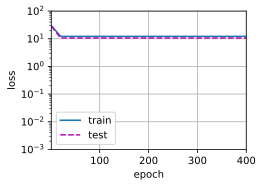

In [21]:
# 从多项式特征中选择前2个维度，即1和x
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

欠拟合（维度少了，拟合不精确）

weight: [[ 4.9806356   1.311945   -3.324305    5.040381   -0.1737222   1.2446555
  -0.04724012  0.18974508 -0.06522573 -0.192753   -0.06892763  0.11589552
  -0.12001784  0.21704714 -0.20166305 -0.02002941 -0.18497555 -0.18634057
  -0.13243198  0.00991324]]


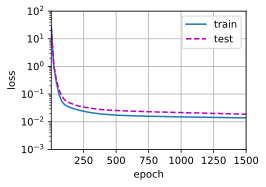

In [22]:
# 从多项式特征中选取所有维度
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=1500)

过拟合